#Mental Health and Wellness Trends

#Data Exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from sklearn.model_selection import train_test_split


In [ ]:
# CDC Datasets:
clinical = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/WHO_NREVSS_Clinical_Labs.csv')
public_health = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/WHO_NREVSS_Public_Health_Labs.csv')

# Google Trends Search Datasets:
fluSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluSearch.csv')
fluVaccSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluVaccSearch.csv')
influenzaSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/influenzaSearch.csv')
congestionSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/congestionSearch.csv')
coldSymptomsSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/coldSymptomsSearch.csv')
fluShotSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluShotSearch.csv')
fluSymptomsSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluSymptomsSearch.csv')
fluOutbreakSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluOutbreakSearch.csv')
sickLeaveLaws = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/sickLeaveLaws.csv')
sickLeaveLaws = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/sickLeaveLaws.csv')
soreThroatSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/soreThroatSearch.csv')
runnyNoseSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/runnyNose.csv')
fluTreatmentSearch = pd.read_csv('https://raw.githubusercontent.com/zainamushtaq/Google_1C/main/fluTreatmentSearch.csv')

In [ ]:
clinical.head()

,REGION TYPE,REGION,YEAR,WEEK,TOTAL SPECIMENS,TOTAL A,TOTAL B,PERCENT POSITIVE,PERCENT A,PERCENT B
0,National,X,2015,40,12029,84,43,1.05578,0.698312,0.357469
1,National,X,2015,41,13111,116,54,1.29662,0.884753,0.411868
2,National,X,2015,42,13441,97,52,1.10855,0.721672,0.386876
3,National,X,2015,43,13537,98,52,1.10807,0.723942,0.384132
4,National,X,2015,44,14687,97,68,1.12344,0.660448,0.462994


In [ ]:
public_health.head()

,REGION TYPE,REGION,YEAR,WEEK,TOTAL SPECIMENS,A (2009 H1N1),A (H3),A (Subtyping not Performed),B,BVic,BYam,H3N2v,A (H5)
0,National,X,2015,40,1139,4,65,2,10,0,1,0,0
1,National,X,2015,41,1152,5,41,2,7,3,0,0,0
2,National,X,2015,42,1198,10,50,1,8,3,2,0,0
3,National,X,2015,43,1244,9,31,4,9,1,4,0,0
4,National,X,2015,44,1465,4,23,4,9,1,4,0,0


In [ ]:
fluSearch.head()

,Month,flu
0,2015-09,9
1,2015-10,17
2,2015-11,11
3,2015-12,11
4,2016-01,10


In [ ]:
fluVaccSearch.head()

,Month,flu vaccine
0,2015-09,30
1,2015-10,53
2,2015-11,24
3,2015-12,13
4,2016-01,8


In [ ]:
influenzaSearch.head()

,Month,influenza
0,2015-09,8
1,2015-10,10
2,2015-11,9
3,2015-12,9
4,2016-01,9


In [ ]:
congestionSearch.head()

,Month,congestion
0,2015-09,32
1,2015-10,32
2,2015-11,34
3,2015-12,39
4,2016-01,43


In [ ]:
coldSymptomsSearch.head()

,Month,cold symptoms
0,2015-09,20
1,2015-10,22
2,2015-11,25
3,2015-12,26
4,2016-01,28


In [ ]:
fluShotSearch.head()

,Month,Flu shot
0,2015-09,20
1,2015-10,50
2,2015-11,25
3,2015-12,11
4,2016-01,7


In [ ]:
fluSymptomsSearch.head()

,Month,Flu symptoms
0,2015-09,7
1,2015-10,10
2,2015-11,10
3,2015-12,11
4,2016-01,11


In [ ]:
fluOutbreakSearch.head()

,Month,Flu outbreak
0,2015-09,3
1,2015-10,3
2,2015-11,3
3,2015-12,3
4,2016-01,4


In [ ]:
sickLeaveLaws.head()

,Month,Sick leave laws
0,2015-09,28
1,2015-10,19
2,2015-11,28
3,2015-12,26
4,2016-01,25


#Data Cleaning

## Google Search Trends Data Cleaning

Combine all of the Google Trends Search Datasets into one dataframe:

In [ ]:
dataframes = [
    fluSearch, fluVaccSearch, influenzaSearch, congestionSearch,
    coldSymptomsSearch, fluShotSearch, fluSymptomsSearch,
    fluOutbreakSearch, sickLeaveLaws, soreThroatSearch, runnyNoseSearch, fluTreatmentSearch
]

# creating a new dataframe to store all search data
# months on every search term is the same, so month column can be taken from any df
searches = pd.DataFrame({'year_month' : fluSearch.iloc[:, 0]})

for data in dataframes:
  searches[data.columns[1]] = data[data.columns[1]]
searches.head()

,year_month,flu,flu vaccine,influenza,congestion,cold symptoms,Flu shot,Flu symptoms,Flu outbreak,Sick leave laws,sore throat,runny nose,Flu treatment
0,2015-09,9,30,8,32,20,20,7,3,28,36,32,9
1,2015-10,17,53,10,32,22,50,10,3,19,33,26,13
2,2015-11,11,24,9,34,25,25,10,3,28,36,25,13
3,2015-12,11,13,9,39,26,11,11,3,26,41,30,14
4,2016-01,10,8,9,43,28,7,11,4,25,41,35,15


Plot the search trends for a simple visualization of any peaks and similar patterns:

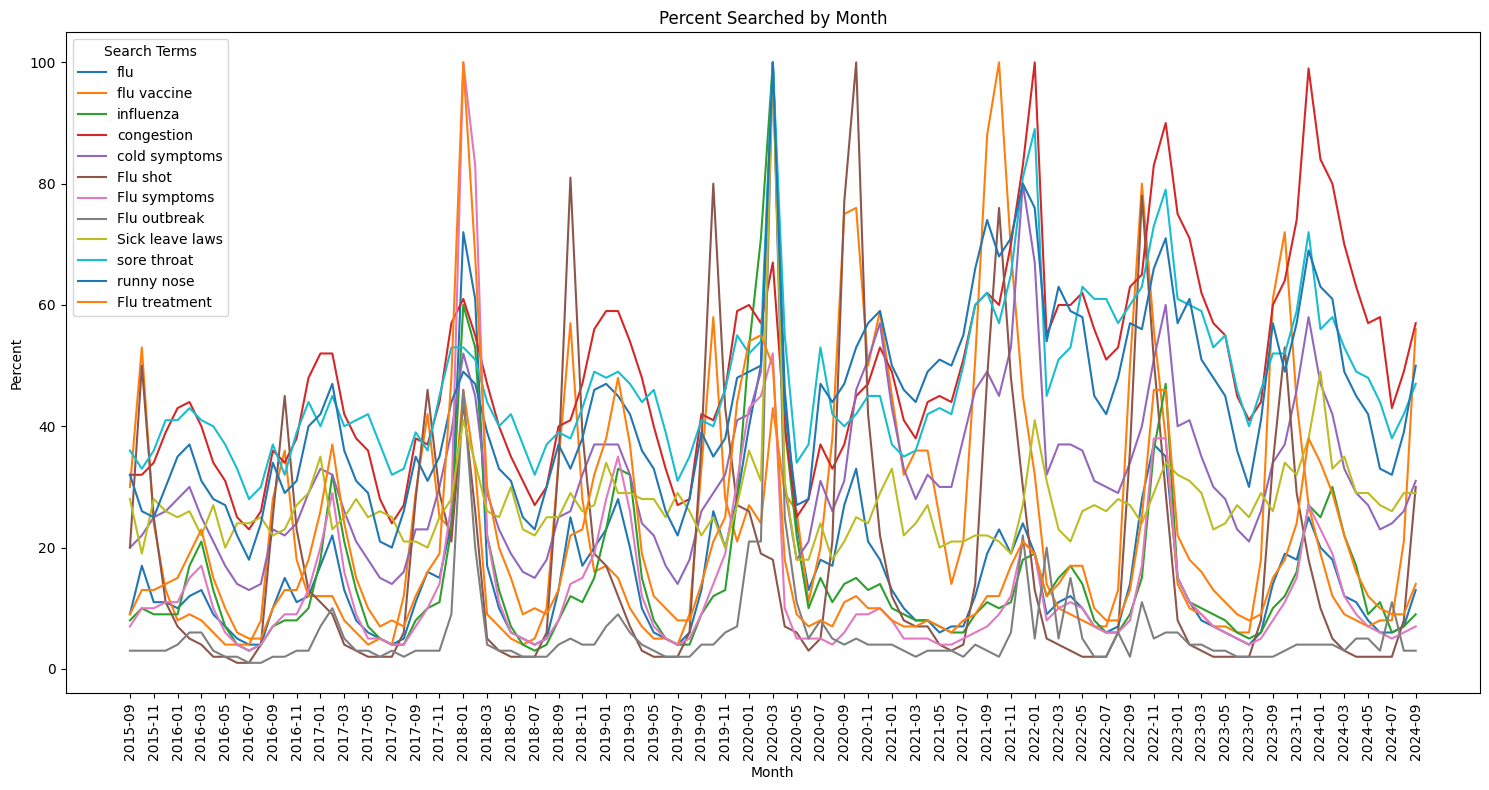

In [ ]:
plt.figure(figsize=(15, 8))

# plot each line
for data in dataframes:
    plt.plot(data.iloc[:, 0], data.iloc[:, 1], linestyle='-', label=data.columns[1])

plt.legend(title="Search Terms")

plt.xlabel('Month')
plt.ylabel('Percent')
plt.title('Percent Searched by Month')

plt.xticks(ticks=range(0, len(fluSearch['Month']), 2), labels=fluSearch['Month'][::2], rotation=90)
plt.tight_layout()

plt.show()

##CDC Flu Datasets Cleaning

In [ ]:
# getting rid of first 2 columns for both dfs, since all are national data so regions are irrelevant
clinical = clinical.iloc[:, 2:]
public_health = public_health.iloc[:, 2:]

In [ ]:
clinical.head()

,YEAR,WEEK,TOTAL SPECIMENS,TOTAL A,TOTAL B,PERCENT POSITIVE,PERCENT A,PERCENT B
0,2015,40,12029,84,43,1.05578,0.698312,0.357469
1,2015,41,13111,116,54,1.29662,0.884753,0.411868
2,2015,42,13441,97,52,1.10855,0.721672,0.386876
3,2015,43,13537,98,52,1.10807,0.723942,0.384132
4,2015,44,14687,97,68,1.12344,0.660448,0.462994


In [ ]:
public_health.head()

,YEAR,WEEK,TOTAL SPECIMENS,A (2009 H1N1),A (H3),A (Subtyping not Performed),B,BVic,BYam,H3N2v,A (H5)
0,2015,40,1139,4,65,2,10,0,1,0,0
1,2015,41,1152,5,41,2,7,3,0,0,0
2,2015,42,1198,10,50,1,8,3,2,0,0
3,2015,43,1244,9,31,4,9,1,4,0,0
4,2015,44,1465,4,23,4,9,1,4,0,0


In [ ]:
cdc = pd.DataFrame()

# copying the year and week columns as they are the same in both dfs
cdc['year'] = clinical['YEAR']
cdc['week'] = clinical['WEEK']

# calculating the new total by adding the totals from both
cdc['total'] = clinical['TOTAL SPECIMENS'] + public_health['TOTAL SPECIMENS']

# calculating the total number of positive tests
# we do not care about type of flu, so we can add them all together
cdc['positive'] = clinical['TOTAL A'] + clinical['TOTAL B'] + public_health.iloc[:, 3:10].sum(axis=1)

cdc['percent'] = 100 * cdc['positive'] / cdc['total']

cdc.head()

,year,week,total,positive,percent
0,2015,40,13168,209,1.587181
1,2015,41,14263,228,1.598542
2,2015,42,14639,223,1.523328
3,2015,43,14781,208,1.407212
4,2015,44,16152,210,1.300149


In [ ]:
# turn year and week into strings
cdc['year'] = cdc['year'].astype(str)
cdc['week'] = cdc['week'].astype(str)

# function to calculate the start date of the week based on year and week number
def get_week_start_date(year, week):
    # convert to a datetime object corresponding to the Monday of the given week
    return pd.to_datetime(f'{year}-W{week}-1', format='%Y-W%W-%w')

# apply the function to create a new 'week_start_date' column
cdc['week_start_date'] = cdc.apply(lambda row: get_week_start_date(row['year'], row['week']), axis=1)

# extract the month from the week_start_date
cdc['month'] = cdc['week_start_date'].dt.month

# create year_month column to make grouping easier
cdc['year_month'] = cdc['year'].astype(str) + "-" + cdc['month'].astype(str)

In [ ]:
cdc.head()

,year,week,total,positive,percent,week_start_date,month,year_month
0,2015,40,13168,209,1.587181,2015-10-05,10,2015-10
1,2015,41,14263,228,1.598542,2015-10-12,10,2015-10
2,2015,42,14639,223,1.523328,2015-10-19,10,2015-10
3,2015,43,14781,208,1.407212,2015-10-26,10,2015-10
4,2015,44,16152,210,1.300149,2015-11-02,11,2015-11


In [ ]:
# group by month and sum all of the total and positive values
cdc_monthly = cdc.groupby('year_month')[['total', 'positive']].sum().reset_index()

# calculate new percentages
cdc_monthly['percent'] = 100 * cdc_monthly['positive'] / cdc_monthly['total']

cdc_monthly.head()

,year_month,total,positive,percent
0,2015-10,56851,868,1.526798
1,2015-11,83443,1314,1.574728
2,2015-12,75497,2201,2.915348
3,2016-1,86167,6270,7.276568
4,2016-10,79979,1857,2.321859


## Merge Datasets (Searches & CDC)

In [ ]:
# convert year_month to datetime
if 'year_month' in cdc_monthly.columns:
    cdc_monthly['year_month'] = pd.to_datetime(cdc_monthly['year_month'], format='%Y-%m')

# extract year and month as numerical features
cdc_monthly['year'] = cdc_monthly['year_month'].dt.year
cdc_monthly['month'] = cdc_monthly['year_month'].dt.month

# create a month column in both dfs to merge on
cdc_monthly['Month'] = cdc_monthly['year_month'].dt.to_period('M').astype(str)
searches['Month'] = pd.to_datetime(searches['year_month'], format='%Y-%m').dt.to_period('M').astype(str)

# merge dfs
merged_data = pd.merge(cdc_monthly, searches, on='Month', how='left')

# merged_data.head()

# create new df for modeling
df = merged_data.copy()
df.drop(columns=['Month'], inplace=True)
df = df.drop(columns=['year_month_x', 'year_month_y'])

df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df.head()

,total,positive,percent,year,month,flu,flu vaccine,influenza,congestion,cold symptoms,Flu shot,Flu symptoms,Flu outbreak,Sick leave laws,sore throat,runny nose,Flu treatment
0,56851,868,1.526798,2015,10,17,53,10,32,22,50,10,3,19,33,26,13
1,83443,1314,1.574728,2015,11,11,24,9,34,25,25,10,3,28,36,25,13
2,75497,2201,2.915348,2015,12,11,13,9,39,26,11,11,3,26,41,30,14
3,86167,6270,7.276568,2016,1,10,8,9,43,28,7,11,4,25,41,35,15
4,79979,1857,2.321859,2016,10,15,36,8,34,22,45,9,2,23,32,29,13


In [ ]:
# final check for missing values ---> there's none
df.isna().sum()

,0
total,0
positive,0
percent,0
year,0
month,0
flu,0
flu vaccine,0
influenza,0
congestion,0
cold symptoms,0


# Modeling

##Splitting the data

In [ ]:
# prepare features and label
X = df.drop(['percent', 'total', 'positive', 'year', 'month'], axis=1)
y = df['percent']

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# first split: 70% training, 30% validation/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=123)

# second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=123)
# X_train, y_train: training data (70%)
# X_val, y_val: validation data (15%)
# X_test, y_test: test data (15%)

## Linear Regression Model

In [ ]:
# imports
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso

###Training

In [ ]:
# initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

###Validation

In [ ]:
# predict on validation data:
y_lr_val = lr_model.predict(X_val)

# evaluate the validation with various metrics
mse = mean_squared_error(y_val, y_lr_val)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_lr_val)
r2 = r2_score(y_val, y_lr_val)

# MSE: avg sqr diff betwn y_test and y_lr_pred --> lower MSE is better
# R-squared value: how well model explains variation in data --> higher R^2 is better (1 is perfect model)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

Mean Squared Error (MSE): 32.7134
R-squared (R²): 0.6218
Root Mean Squared Error (RMSE): 5.7196
Mean Absolute Error (MAE): 3.4725


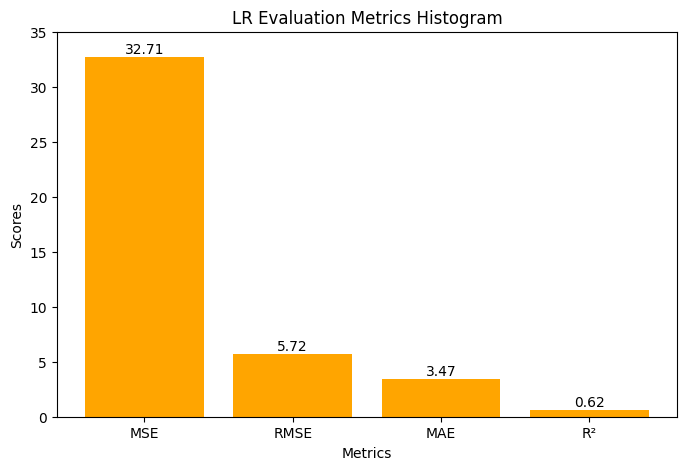

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your computed scores
lr_mse = mean_squared_error(y_val, y_lr_val)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_val, y_lr_val)
lr_r2 = r2_score(y_val, y_lr_val)

# List of scores and their labels
scores = [lr_mse, lr_rmse, lr_mae, lr_r2]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# Create a histogram
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color='orange')  # Set color to orange

plt.ylim(0, 35)

plt.title('LR Evaluation Metrics Histogram')
plt.xlabel('Metrics')
plt.ylabel('Scores')

# Annotate bars with exact numbers
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{score:.2f}', ha='center', va='bottom')

plt.show()


### Testing

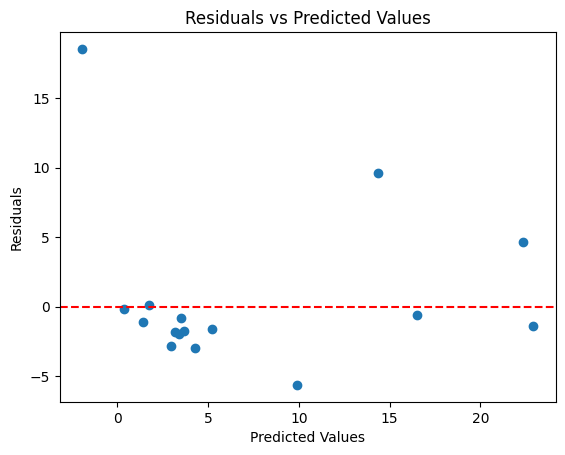

In [ ]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_val - y_lr_val

plt.scatter(y_lr_val, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

In [ ]:
# make predictions on test data
y_lr_pred = lr_model.predict(X_test)

# evaluate the model with various metrics
lr_mse = mean_squared_error(y_test, y_lr_pred)
lr_rmse = np.sqrt(mse)
lr_mae = mean_absolute_error(y_test, y_lr_pred)
lr_r2 = r2_score(y_test, y_lr_pred)

# MSE: avg sqr diff betwn y_test and y_lr_pred --> lower MSE = better
# R-squared value: how well model explains variation in data -->higher R^2 = better
print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"R-squared (R²): {lr_r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {lr_mae:.4f}")

Mean Squared Error (MSE): 11.6143
R-squared (R²): 0.7514
Root Mean Squared Error (RMSE): 5.7196
Mean Absolute Error (MAE): 2.7357


In [ ]:
# Ridge Model ==> negative cross-validation scores BAD
# List to maintain the different cross-validation scores
cross_val_scores_ridge = []

# List to maintain the different values of alpha
alpha = []

# Loop to compute the different values of cross-validation scores
for i in range(1, 9):
    ridgeModel = Ridge(alpha = i * 0.25)
    ridgeModel.fit(X_train, y_train)
    scores = cross_val_score(ridgeModel, X, y, cv = 10)
    avg_cross_val_score = np.mean(scores)*100
    cross_val_scores_ridge.append(avg_cross_val_score)
    alpha.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
    print(str(alpha[i])+' : '+str(cross_val_scores_ridge[i]))

0.25 : 38.07420005743031
0.5 : 38.20400389610869
0.75 : 38.33166991249676
1.0 : 38.457239773620785
1.25 : 38.58075417626986
1.5 : 38.70225287347182
1.75 : 38.821774700224324
2.0 : 38.939357598366655


In [ ]:
# Lasso Model ==> negative cross-validation scores BAD
# List to maintain the cross-validation scores
cross_val_scores_lasso = []

# List to maintain the different values of Lambda
Lambda = []

# Loop to compute the cross-validation scores
for i in range(1, 9):
    lassoModel = Lasso(alpha = i * 0.25, tol = 0.0925)
    lassoModel.fit(X_train, y_train)
    scores = cross_val_score(lassoModel, X, y, cv = 10)
    avg_cross_val_score = np.mean(scores)*100
    cross_val_scores_lasso.append(avg_cross_val_score)
    Lambda.append(i * 0.25)

# Loop to print the different values of cross-validation scores
for i in range(0, len(alpha)):
    print(str(alpha[i])+' : '+str(cross_val_scores_lasso[i]))

0.25 : 29.60093884497774
0.5 : 29.669994409366275
0.75 : 30.877782192549034
1.0 : 31.276447919604212
1.25 : 32.34997782831456
1.5 : 34.34653428792499
1.75 : 35.94880289153078
2.0 : 36.66826679096668


### Conclusion
When the relationship between independent and dependent variables is nonlinear, linear regression might not perform wel. Linear Regression assumes:

1.  The relationship between the predictors and the target is linear (or can be transformed to linear).

2.   The residuals (errors) are normally distributed and have constant variance.

**Model Performance:**

*   LR model score:  0.7345146163447065
* Mean Squared Error (MSE): 23.4218
* R-squared (R²): 0.7345
* Root Mean Squared Error (RMSE): 4.8396
* Mean Absolute Error (MAE): 3.7686


**We need to consider the peak nature of our data❗**

## Random Forest

In [ ]:
param_grid = {
    'n_estimators': [200, 225,250],
    'max_depth': [None, 5, 7], # most impactful to model perf
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'] # most impactful to model perf
}

### Training

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create a Random Forest model
rf_model = RandomForestRegressor(random_state=123)

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1)

# Fit the model
grid_search.fit(X_val, y_val)

# Get the best parameters and score
best_params = grid_search.best_params_

print(f"Best Parameters: {best_params}")


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


### Validation

In [ ]:
# initialize and train the Random Forest model
rf_model = RandomForestRegressor(**best_params, random_state=123)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=200,
                      random_state=123)

In [ ]:
# predict on validation data:
y_rf_val = rf_model.predict(X_val)

# evaluate the validation with various metrics
mse = mean_squared_error(y_val, y_rf_val)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_rf_val)
r2 = r2_score(y_val, y_rf_val)

# MSE: avg sqr diff betwn y_test and y_lr_pred --> lower MSE is better
# R-squared value: how well model explains variation in data --> higher R^2 is better (1 is perfect model)

print(f"R-squared (R²): {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")

R-squared (R²): 0.8517
Mean Squared Error (MSE): 12.8242
Root Mean Squared Error (RMSE): 3.5811
Mean Absolute Error (MAE): 2.5409


### Testing

In [ ]:
# predict on test data:
y_rf_pred = rf_model.predict(X_test)

# evaluate the model with various metrics
rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)

# print metrics
print(f"Mean Squared Error (MSE): {rf_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.4f}")
print(f"Mean Absolute Error (MAE): {rf_mae:.4f}")
print(f"R-squared (R²): {rf_r2:.4f}")

Mean Squared Error (MSE): 9.7967
Root Mean Squared Error (RMSE): 3.1300
Mean Absolute Error (MAE): 2.4485
R-squared (R²): 0.7903


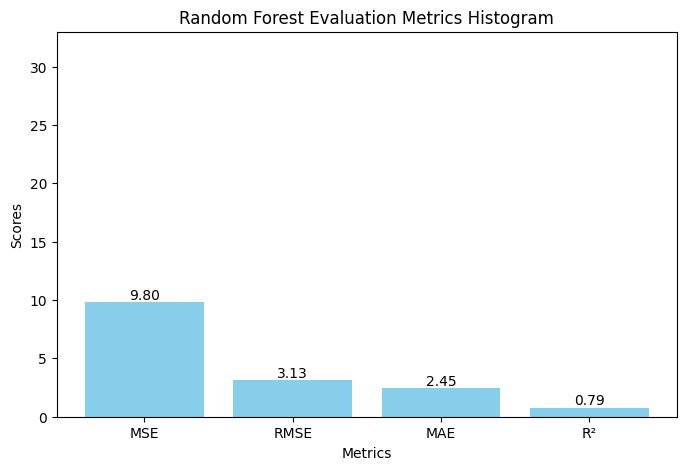

In [ ]:
import matplotlib.pyplot as plt

# List of scores and their labels
scores = [rf_mse, rf_rmse, rf_mae, rf_r2]
labels = ['MSE', 'RMSE', 'MAE', 'R²']

# Create a histogram
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, scores, color='skyblue')  # Set color to blue

plt.ylim(0, 33)

plt.title('Random Forest Evaluation Metrics Histogram')
plt.xlabel('Metrics')
plt.ylabel('Scores')

# Annotate bars with exact numbers
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{score:.2f}', ha='center', va='bottom')

plt.show()


# Model Comparison

**LR Performance**
* LR model score/ R-squared:  0.7345146163447065
* Mean Squared Error (MSE): 23.4218
* Root Mean Squared Error (RMSE): 4.8396
* Mean Absolute Error (MAE): 3.7686


**RF Performance**
* RF model score/ R-squared:  0.7903
* Mean Squared Error (MSE): 9.7967
* Root Mean Squared Error (RMSE): 3.5811
* Mean Absolute Error (MAE): 2.4485


RF performs better than LR.

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html

find peaks algo

create one train, test, split to use for all models
graph all model

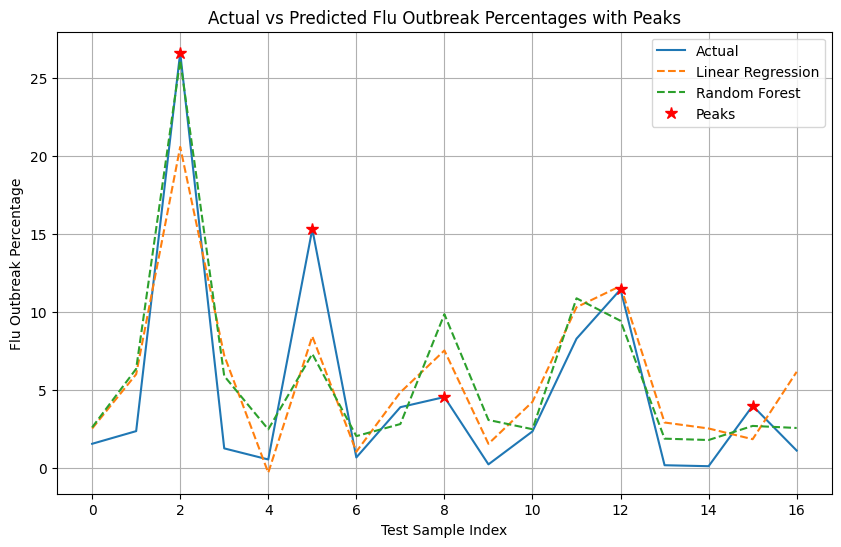

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Assuming y_test, y_lr_pred, and y_rf_pred are defined.

# Find the peaks in the actual values
peaks, _ = find_peaks(y_test.values)

# Plot the predictions vs actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_lr_pred, label='Linear Regression', linestyle='--')
plt.plot(y_rf_pred, label='Random Forest', linestyle='--')

# Mark the peaks
plt.plot(peaks, y_test.values[peaks], 'r*', markersize=9, label='Peaks')

plt.legend()
plt.title('Actual vs Predicted Flu Outbreak Percentages with Peaks')
plt.xlabel('Test Sample Index')
plt.ylabel('Flu Outbreak Percentage')
plt.grid()
plt.show()


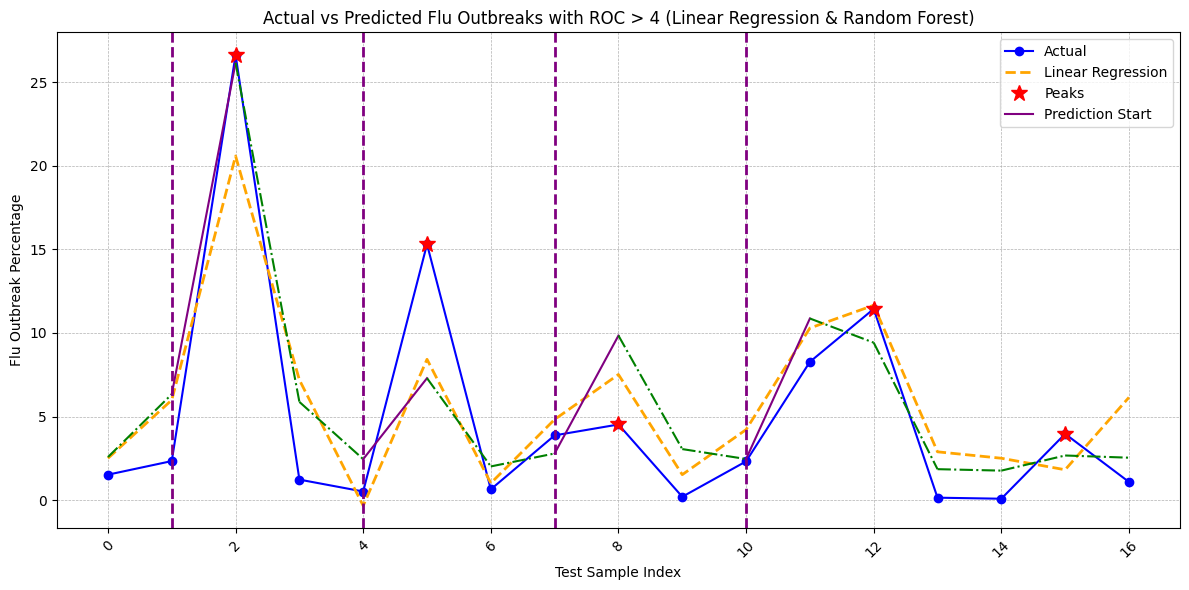

In [ ]:
# Assuming y_test, y_lr_pred, and y_rf_pred are defined.

# Find the peaks in the actual values
peaks, _ = find_peaks(y_test.values)

# Calculate the rate of change for y_rf_pred
rate_of_change_rf = np.diff(y_rf_pred)

# Threshold for high rate of change
threshold = 4

# Create the plot
plt.figure(figsize=(12, 6))

# Plot the actual values and Linear Regression predictions
plt.plot(y_test.values, label='Actual', marker='o', color='blue', linestyle='-', markersize=6)
plt.plot(y_lr_pred, label='Linear Regression', linestyle='--', color='orange', linewidth=2)

# Plot y_rf_pred with rate-based color coding
for i in range(len(y_rf_pred) - 1):
    # If rate of change exceeds the threshold for Random Forest, use purple; otherwise, use default color
    if rate_of_change_rf[i] > threshold:  # High increase in interest
        color = 'purple'
        linestyle = 'solid'
        # Highlight the start of the prediction peak with a vertical line or marker
        if i == 0 or rate_of_change_rf[i-1] <= threshold:
            plt.axvline(x=i, color='purple', linestyle='--', linewidth=2)  # Highlight the start
    else:
        color = 'green'
        linestyle = 'dashdot'

    # Plotting the lines with specified colors and styles
    plt.plot([i, i + 1], [y_rf_pred[i], y_rf_pred[i + 1]], color=color, linestyle=linestyle)

# Mark the peaks on y_test
plt.plot(peaks, y_test.values[peaks], 'r*', markersize=12, label='Peaks')

# Avoid duplicate entries in legend for Random Forest and Linear Regression
plt.plot([], [], color='purple', linestyle='-', label='Prediction Start')

# Set up the rest of the plot
plt.legend(loc='best')
plt.title('Actual vs Predicted Flu Outbreaks with ROC > 4 (Linear Regression & Random Forest)')
plt.xlabel('Test Sample Index')  # If you have a time-based index, update this label
plt.ylabel('Flu Outbreak Percentage')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Rotate x-axis labels if necessary for better readability (in case you have many samples)
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()  # This adjusts the layout to avoid overlapping labels
plt.show()

# Rate of Change
When the diff between any 2 points is greater than 6 (flu outbreak percentage) in our Random Forest prediction model, the line turns to solid purple. This high rate of increase can be used to notify the public health officials and people of the alarming online concern for flu related search terms, indicating many people are getting sick.

Similarly, we can do the opposite and find out when the popularity for the search terms decrease by checking the rate of change/ differences between any 2 points against a different threshold. If it's any lower than that, stakeholders can understand the problem is diminishing.

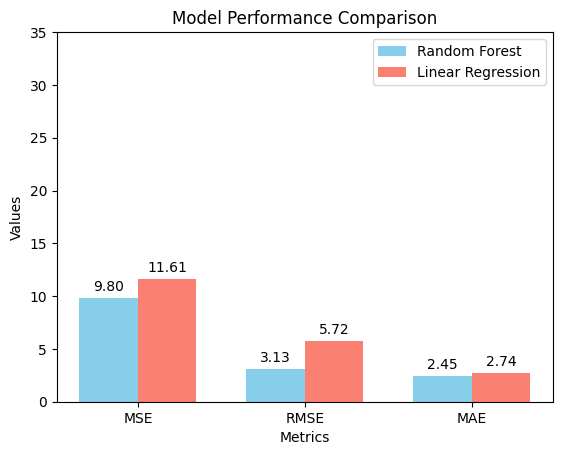

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample metric values for both models (replace these with your actual values)
metrics = {
    'Linear Regression': [lr_mse, lr_rmse, lr_mae],  # MSE, RMSE, MAE for Linear Regression
    'Random Forest': [rf_mse, rf_rmse, rf_mae]  # MSE, RMSE, MAE for Random Forest
}
metric_names = ['MSE', 'RMSE', 'MAE']

# Set up the positions and width for bars
x = np.arange(len(metric_names))  # the label locations
width = 0.35  # width of the bars

# Create the bar plot
fig, ax = plt.subplots()
bars_rf = ax.bar(x - width/2, metrics['Random Forest'], width, label='Random Forest', color='skyblue')
bars_lr = ax.bar(x + width/2, metrics['Linear Regression'], width, label='Linear Regression', color='salmon')

plt.ylim(0, 35)

# Add labels, title, and custom x-axis tick labels
ax.set_xlabel('Metrics')
ax.set_ylabel('Values')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.legend()  # Add legend to differentiate between models

# Add values on top of each bar for clarity
for bars in [bars_rf, bars_lr]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.show()



#Gradients boosting in RF



```



# Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# prepare features and label
X = df.drop(['percent', 'total', 'positive', 'year', 'month'], axis=1)
# print(X)
y = df['percent']

scaler = StandardScaler()
normalized_features = scaler.fit_transform(X)

In [ ]:
# number of clusters = 4 clusters for seasonal patterns
kmeans = KMeans(n_clusters=4, random_state=123)
X['Cluster'] = kmeans.fit_predict(normalized_features)

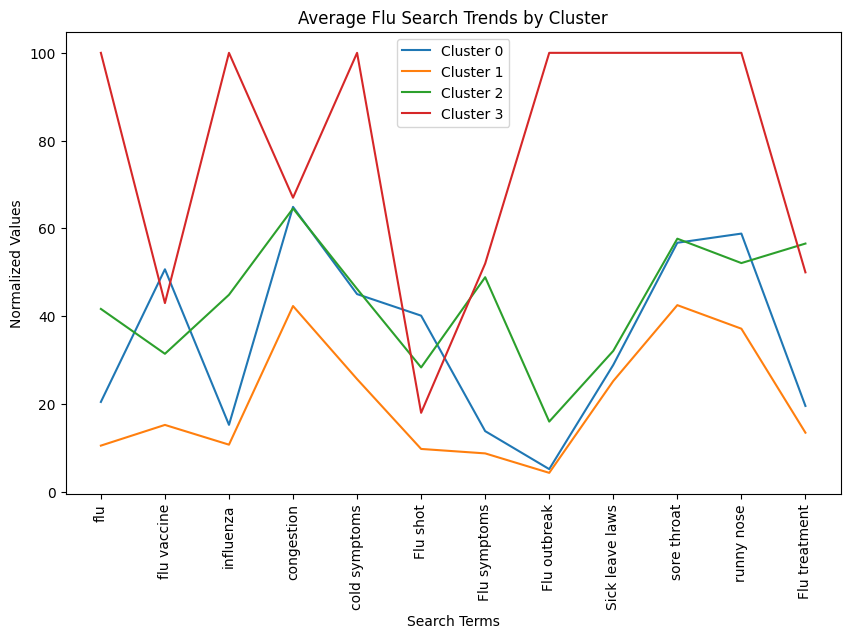

In [ ]:
# Group data by clusters and calculate mean trends
cluster_means = X.groupby('Cluster').mean()

# Plot each cluster’s average trends
plt.figure(figsize=(10, 6))
for i in range(4):  # Number of clusters
    plt.plot(cluster_means.iloc[i], label=f'Cluster {i}')

plt.legend()
plt.title('Average Flu Search Trends by Cluster')
plt.xlabel('Search Terms')
plt.xticks(rotation='vertical')
plt.ylabel('Normalized Values')
plt.show()



# Analysis:
* spikes indicate that search term is correlated to the cluster

In [ ]:
# #cross check
# filtered_data = df[(df['Cluster'] == 2) & (df['month'] == 11)]

# # Count the occurrences
# count = len(filtered_data)
# print(f"Cluster 2 appears in Month 1: {count} times")


# Count the number of months in each cluster
month_cluster_dist = df.groupby(['Cluster', 'month']).size().unstack()

# Plot the month distribution across clusters
plt.figure(figsize=(14, 8))
month_cluster_dist.T.plot(kind='bar', stacked=True, cmap='viridis')

plt.title('Month Distribution Across Clusters')
plt.xlabel('Month')
plt.ylabel('Count of Months in Each Cluster')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')




KeyError: 'Cluster'

In [ ]:
X_aligned = X.iloc[:, :kmeans.cluster_centers_.shape[1]]

# Create cluster centers DataFrame
cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=X_aligned.columns)

# Add cluster labels for clarity
cluster_centers.index = [f"Cluster {i}" for i in range(len(cluster_centers))]

# Transpose for better visualization (features as rows, clusters as columns)
cluster_contributions = cluster_centers.T

# Shift values to remove negatives
cluster_contributions_shifted = cluster_contributions - cluster_contributions.min().min()

# Normalize across clusters for each feature to get relative percentages
relative_percentages = cluster_contributions_shifted.div(cluster_contributions_shifted.sum(axis=1), axis=0) * 100

# Define a custom color palette
custom_colors = ["#2E86C1", "#FFC0CB", "#28B463", "#F1C40F"]  # Add more colors if needed

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))
bars = relative_percentages.plot(kind='bar', stacked=True, color=custom_colors, figsize=(14, 8), ax=ax)

# Add relative percentage annotations on each bar segment
for feature_idx, bar_group in enumerate(ax.containers):  # Loop through each bar group
    for bar in bar_group:  # Loop through each segment of the bar
        height = bar.get_height()
        if height > 0:  # Only annotate non-zero segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,  # X-coordinate (center of the segment)
                bar.get_y() + height / 2,  # Y-coordinate (center of the segment)
                f"{height:.1f}%",  # Format percentage with one decimal
                ha='center', va='center', fontsize=10, color='black'
            )

# Customize the chart
plt.title('Relative Feature Contribution to Each Cluster (in %)', fontsize=16)
plt.xlabel('Search Terms (Features)', fontsize=14)
plt.ylabel('Relative Contribution (%)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


# Things to think about:


*   Why does cluster 3 (yellow) contribute so much to each search term? (except agruably flu shot, flu vaccine, congestion, and flu treatment)
* With cluster 3 (yellow) having so much contribution, why is it only prevalent in March and nowhere else?
* Why does cluster 1 (pink) consistently have little to no contribution across all search terms (range is only from 0.6 - 3%)
* what can we take away from cluster 0 and cluster 2 (blue and green) contribution levels?

website dashboard ideas
- figma design
- parts split up


In [ ]:
from sklearn.decomposition import PCA
feature_columns = df.drop(['percent', 'total', 'positive', 'year', 'month', 'Cluster'], axis=1)

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
df[['PC1', 'PC2']] = pca.fit_transform(df[feature_columns])  # Replace 'feature_columns' with the list of features

# Scatter plot using PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=100, alpha=0.7)

# Add titles and labels
plt.title('Cluster Map with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


In [ ]:
print(df.dtypes)
